In [1]:
"""
# 01 - Build Feature Table from Previous 3D MicroCT Segmentation

This notebook reuses the segmentation outputs generated in:

"projects/02_microct_subvolume_3d_analysis"

The goal is not to repeat the segmentation step, but to transform the already segmented 3D microCT volume into a quantitative feature table 
suitable for process monitoring and anomaly detection.

Main outputs:

- "features_by_slice.csv"
- representative visual checks of the previous segmentation
- phase fraction profiles along the z-axis
- intensity and heterogeneity profiles
"""

'\n# 01 - Build Feature Table from Previous 3D MicroCT Segmentation\n\nThis notebook reuses the segmentation outputs generated in:\n\n"projects/02_microct_subvolume_3d_analysis"\n\nThe goal is not to repeat the segmentation step, but to transform the already segmented 3D microCT volume into a quantitative feature table \nsuitable for process monitoring and anomaly detection.\n\nMain outputs:\n\n- "features_by_slice.csv"\n- representative visual checks of the previous segmentation\n- phase fraction profiles along the z-axis\n- intensity and heterogeneity profiles\n'

In [2]:
# ------------------------------------------------------------
# 01 - Build feature table from previous 3D segmentation
# ------------------------------------------------------------

from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import measure
from skimage.measure import regionprops_table

# Optional: only needed if we load TIFF stacks
try:
    import tifffile as tiff
except ImportError:
    tiff = None

# ------------------------------------------------------------
# Matplotlib default configuration
# ------------------------------------------------------------

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = False

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
# This notebook is expected to be inside:
# projects/03_3d_microct_process_monitoring/notebooks/
#
# Therefore:
# notebook_dir      = .../projects/03_3d_microct_process_monitoring/notebooks
# current_project   = .../projects/03_3d_microct_process_monitoring
# projects_dir      = .../projects
# previous_project  = .../projects/02_microct_subvolume_3d_analysis
# ------------------------------------------------------------

NOTEBOOK_DIR = Path.cwd()

# If the notebook is executed from its own folder, this works directly.
# If not, adjust CURRENT_PROJECT manually.
CURRENT_PROJECT = NOTEBOOK_DIR.parent
PROJECTS_DIR = CURRENT_PROJECT.parent

PREVIOUS_PROJECT = PROJECTS_DIR / "02_microct_subvolume_3d_analysis"

FIGURES_DIR = CURRENT_PROJECT / "figures" / "01_feature_table"
OUTPUTS_DIR = CURRENT_PROJECT / "outputs"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("Current project:")
print(CURRENT_PROJECT)

print("\nPrevious project:")
print(PREVIOUS_PROJECT)

print("\nFigures will be saved in:")
print(FIGURES_DIR)

print("\nOutputs will be saved in:")
print(OUTPUTS_DIR)

Current project:
C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring

Previous project:
C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis

Figures will be saved in:
C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\figures\01_feature_table

Outputs will be saved in:
C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\outputs


In [5]:
# ------------------------------------------------------------
# Search useful files from the previous project
# ------------------------------------------------------------
# We look for common output formats used in segmentation workflows:
# .npy, .npz, .tif, .tiff, .csv
#
# To avoid printing a very long list, we only display the first files.
# ------------------------------------------------------------

extensions = ["*.npy", "*.npz", "*.tif", "*.tiff", "*.csv"]

found_files = []

for ext in extensions:
    found_files.extend(PREVIOUS_PROJECT.rglob(ext))

found_files = sorted(found_files)

n_show = 6

print(f"Found {len(found_files)} candidate files in previous project.")
print(f"Showing first {min(n_show, len(found_files))} files:\n")

for i, file in enumerate(found_files[:n_show]):
    relative_path = file.relative_to(PREVIOUS_PROJECT)
    print(f"[{i:02d}] {relative_path}")

if len(found_files) > n_show:
    print(f"\n... {len(found_files) - n_show} additional files not shown.")

Found 459 candidate files in previous project.
Showing first 6 files:

[00] data\processed\material_mask.npy
[01] data\processed\phase_labels_3class.npy
[02] data\processed\pores_mask.npy
[03] data\processed\resin_mask.npy
[04] data\processed\resin_mask_refined_ge50.npy
[05] data\raw\DatosSubV\DatosSubV0000.tif

... 453 additional files not shown.


In [6]:
# ------------------------------------------------------------
# Select files from previous project
# ------------------------------------------------------------
# This project reuses the outputs generated in:
# projects/02_microct_subvolume_3d_analysis
#
# We do not duplicate raw data in the current project.
# ------------------------------------------------------------

# Original TIFF stack folder from Project 02
ORIGINAL_STACK_DIR = PREVIOUS_PROJECT / "data" / "raw" / "DatosSubV"

# Processed segmentation outputs from Project 02
PHASE_LABELS_PATH = PREVIOUS_PROJECT / "data" / "processed" / "phase_labels_3class.npy"

PORE_MASK_PATH = PREVIOUS_PROJECT / "data" / "processed" / "pores_mask.npy"

# Use the refined resin mask, because this was the final cleaned version
# adopted in the previous project.
RESIN_MASK_PATH = PREVIOUS_PROJECT / "data" / "processed" / "resin_mask_refined_ge50.npy"

# Material/matrix mask from previous project
MATERIAL_MASK_PATH = PREVIOUS_PROJECT / "data" / "processed" / "material_mask.npy"

# Print paths to verify
paths_to_check = {
    "original_stack_dir": ORIGINAL_STACK_DIR,
    "phase_labels_3class": PHASE_LABELS_PATH,
    "pore_mask": PORE_MASK_PATH,
    "resin_mask_refined_ge50": RESIN_MASK_PATH,
    "material_mask": MATERIAL_MASK_PATH,
}

for name, path in paths_to_check.items():
    print(f"{name}: {path}")
    print(f"  exists: {path.exists()}")

original_stack_dir: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\raw\DatosSubV
  exists: True
phase_labels_3class: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\processed\phase_labels_3class.npy
  exists: True
pore_mask: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\processed\pores_mask.npy
  exists: True
resin_mask_refined_ge50: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\processed\resin_mask_refined_ge50.npy
  exists: True
material_mask: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\processed\material_mask.npy
  exists: True


In [7]:
# ------------------------------------------------------------
# Helper function to load volumes
# ------------------------------------------------------------
# Supported formats:
# - .npy
# - .npz
# - .tif / .tiff
# ------------------------------------------------------------

def load_volume(path: Path, npz_key: str | None = None) -> np.ndarray:
    """
    Load a 3D volume from .npy, .npz, .tif or .tiff.

    Parameters
    ----------
    path : Path
        Path to the volume file.
    npz_key : str or None
        Key to use if loading from a .npz file.

    Returns
    -------
    volume : np.ndarray
        Loaded 3D volume.
    """
    
    path = Path(path)
    
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    
    suffix = path.suffix.lower()
    
    if suffix == ".npy":
        volume = np.load(path)
    
    elif suffix == ".npz":
        data = np.load(path)
        
        if npz_key is None:
            print("Available keys in npz file:")
            print(list(data.keys()))
            raise ValueError("Please provide npz_key.")
        
        volume = data[npz_key]
    
    elif suffix in [".tif", ".tiff"]:
        if tiff is None:
            raise ImportError("tifffile is not installed. Install it or use .npy files.")
        volume = tiff.imread(path)
    
    else:
        raise ValueError(f"Unsupported file format: {suffix}")
    
    return volume

In [9]:
# ------------------------------------------------------------
# Helper functions to load volumes and TIFF stacks
# ------------------------------------------------------------
# Supported inputs:
# - Single .npy volume
# - Single .npz volume
# - Single .tif/.tiff volume
# - Folder containing a TIFF stack
# ------------------------------------------------------------

def load_volume(path: Path, npz_key: str | None = None) -> np.ndarray:
    """
    Load a 3D volume from .npy, .npz, .tif or .tiff.

    Parameters
    ----------
    path : Path
        Path to the volume file.
    npz_key : str or None
        Key to use if loading from a .npz file.

    Returns
    -------
    volume : np.ndarray
        Loaded 3D volume.
    """
    
    path = Path(path)
    
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    
    suffix = path.suffix.lower()
    
    if suffix == ".npy":
        volume = np.load(path)
    
    elif suffix == ".npz":
        data = np.load(path)
        
        if npz_key is None:
            print("Available keys in npz file:")
            print(list(data.keys()))
            raise ValueError("Please provide npz_key.")
        
        volume = data[npz_key]
    
    elif suffix in [".tif", ".tiff"]:
        if tiff is None:
            raise ImportError("tifffile is not installed. Install it or use .npy files.")
        volume = tiff.imread(path)
    
    else:
        raise ValueError(f"Unsupported file format: {suffix}")
    
    return volume


def load_tiff_stack(folder: Path, pattern: str = "*.tif") -> np.ndarray:
    """
    Load a folder containing a TIFF stack and build a 3D volume.

    Parameters
    ----------
    folder : Path
        Folder containing TIFF slices.
    pattern : str
        File pattern used to find TIFF files.

    Returns
    -------
    volume : np.ndarray
        3D volume with shape (n_slices, height, width).
    """
    
    folder = Path(folder)
    
    if not folder.exists():
        raise FileNotFoundError(f"Folder not found: {folder}")
    
    files = sorted(folder.glob(pattern))
    
    # If no .tif files are found, try .tiff
    if len(files) == 0:
        files = sorted(folder.glob("*.tiff"))
    
    if len(files) == 0:
        raise FileNotFoundError(f"No TIFF files found in: {folder}")
    
    print(f"Found {len(files)} TIFF slices.")
    print(f"First file: {files[0].name}")
    print(f"Last file : {files[-1].name}")
    
    slices = []
    
    for file in files:
        slices.append(tiff.imread(file))
    
    volume = np.stack(slices, axis=0)
    
    return volume

In [10]:
# ------------------------------------------------------------
# Load previous segmentation outputs
# ------------------------------------------------------------
# The original volume is loaded from the TIFF stack stored in Project 02.
# The segmentation masks are loaded from the processed outputs of Project 02.
# ------------------------------------------------------------

volume = load_tiff_stack(ORIGINAL_STACK_DIR)

mask_pores = load_volume(PORE_MASK_PATH).astype(bool)
mask_resin = load_volume(RESIN_MASK_PATH).astype(bool)

material_mask = load_volume(MATERIAL_MASK_PATH).astype(bool)

# ------------------------------------------------------------
# Define matrix mask
# ------------------------------------------------------------
# Important:
# material_mask may represent the whole solid/material region.
# To avoid overlap with resin and pores, we define matrix as:
#
# matrix = material - resin - pores
#
# This gives us mutually exclusive phase masks.
# ------------------------------------------------------------

mask_matrix = material_mask & (~mask_resin) & (~mask_pores)

print("Loaded volumes:")
print(f"volume shape        : {volume.shape}, dtype: {volume.dtype}")
print(f"mask_pores shape    : {mask_pores.shape}, dtype: {mask_pores.dtype}")
print(f"mask_resin shape    : {mask_resin.shape}, dtype: {mask_resin.dtype}")
print(f"material_mask shape : {material_mask.shape}, dtype: {material_mask.dtype}")
print(f"mask_matrix shape   : {mask_matrix.shape}, dtype: {mask_matrix.dtype}")

# Basic consistency check
assert volume.shape == mask_pores.shape == mask_resin.shape == material_mask.shape == mask_matrix.shape, \
    "Volume and masks must have the same shape."

print("\nAll volumes have consistent shapes.")

Found 435 TIFF slices.
First file: DatosSubV0000.tif
Last file : DatosSubV0434.tif
Loaded volumes:
volume shape        : (435, 178, 202), dtype: uint8
mask_pores shape    : (435, 178, 202), dtype: bool
mask_resin shape    : (435, 178, 202), dtype: bool
material_mask shape : (435, 178, 202), dtype: bool
mask_matrix shape   : (435, 178, 202), dtype: bool

All volumes have consistent shapes.


In [11]:
# ------------------------------------------------------------
# Physical scale
# ------------------------------------------------------------
# Effective voxel size used for this dataset.
#
# In the previous project, the original pixel size was 20 µm,
# but this working subvolume was treated with an effective voxel
# size of 80 µm due to 4x scaling.
# ------------------------------------------------------------

VOXEL_SIZE_UM = 80.0

voxel_area_um2 = VOXEL_SIZE_UM ** 2
voxel_volume_um3 = VOXEL_SIZE_UM ** 3

print(f"Voxel size      : {VOXEL_SIZE_UM:.1f} µm")
print(f"Voxel area      : {voxel_area_um2:.1f} µm²")
print(f"Voxel volume    : {voxel_volume_um3:.1f} µm³")
print(f"Volume shape    : {volume.shape}")
print(f"Number of slices: {volume.shape[0]}")

Voxel size      : 80.0 µm
Voxel area      : 6400.0 µm²
Voxel volume    : 512000.0 µm³
Volume shape    : (435, 178, 202)
Number of slices: 435


In [12]:
# ------------------------------------------------------------
# Mask consistency check
# ------------------------------------------------------------
# We verify that the three phase masks are mutually exclusive:
# - pores
# - resin
# - matrix
#
# We also check how much of the full image is assigned to any phase.
# ------------------------------------------------------------

total_voxels = volume.size

overlap_pores_resin = np.logical_and(mask_pores, mask_resin).sum()
overlap_pores_matrix = np.logical_and(mask_pores, mask_matrix).sum()
overlap_resin_matrix = np.logical_and(mask_resin, mask_matrix).sum()

assigned_mask = mask_pores | mask_resin | mask_matrix
assigned_voxels = assigned_mask.sum()
unassigned_voxels = total_voxels - assigned_voxels

print("Mask overlap check:")
print(f"pores ∩ resin   : {overlap_pores_resin} voxels "
      f"({100 * overlap_pores_resin / total_voxels:.6f} %)")

print(f"pores ∩ matrix  : {overlap_pores_matrix} voxels "
      f"({100 * overlap_pores_matrix / total_voxels:.6f} %)")

print(f"resin ∩ matrix  : {overlap_resin_matrix} voxels "
      f"({100 * overlap_resin_matrix / total_voxels:.6f} %)")

print("\nAssigned / unassigned voxels:")
print(f"assigned voxels   : {assigned_voxels} "
      f"({100 * assigned_voxels / total_voxels:.2f} %)")

print(f"unassigned voxels : {unassigned_voxels} "
      f"({100 * unassigned_voxels / total_voxels:.2f} %)")

print("\nGlobal phase fractions:")
print(f"pore fraction   : {mask_pores.mean():.4f}")
print(f"resin fraction  : {mask_resin.mean():.4f}")
print(f"matrix fraction : {mask_matrix.mean():.4f}")

Mask overlap check:
pores ∩ resin   : 0 voxels (0.000000 %)
pores ∩ matrix  : 0 voxels (0.000000 %)
resin ∩ matrix  : 0 voxels (0.000000 %)

Assigned / unassigned voxels:
assigned voxels   : 15577316 (99.59 %)
unassigned voxels : 63544 (0.41 %)

Global phase fractions:
pore fraction   : 0.0123
resin fraction  : 0.2047
matrix fraction : 0.7789


Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\figures\01_feature_table\representative_slices_with_masks.png


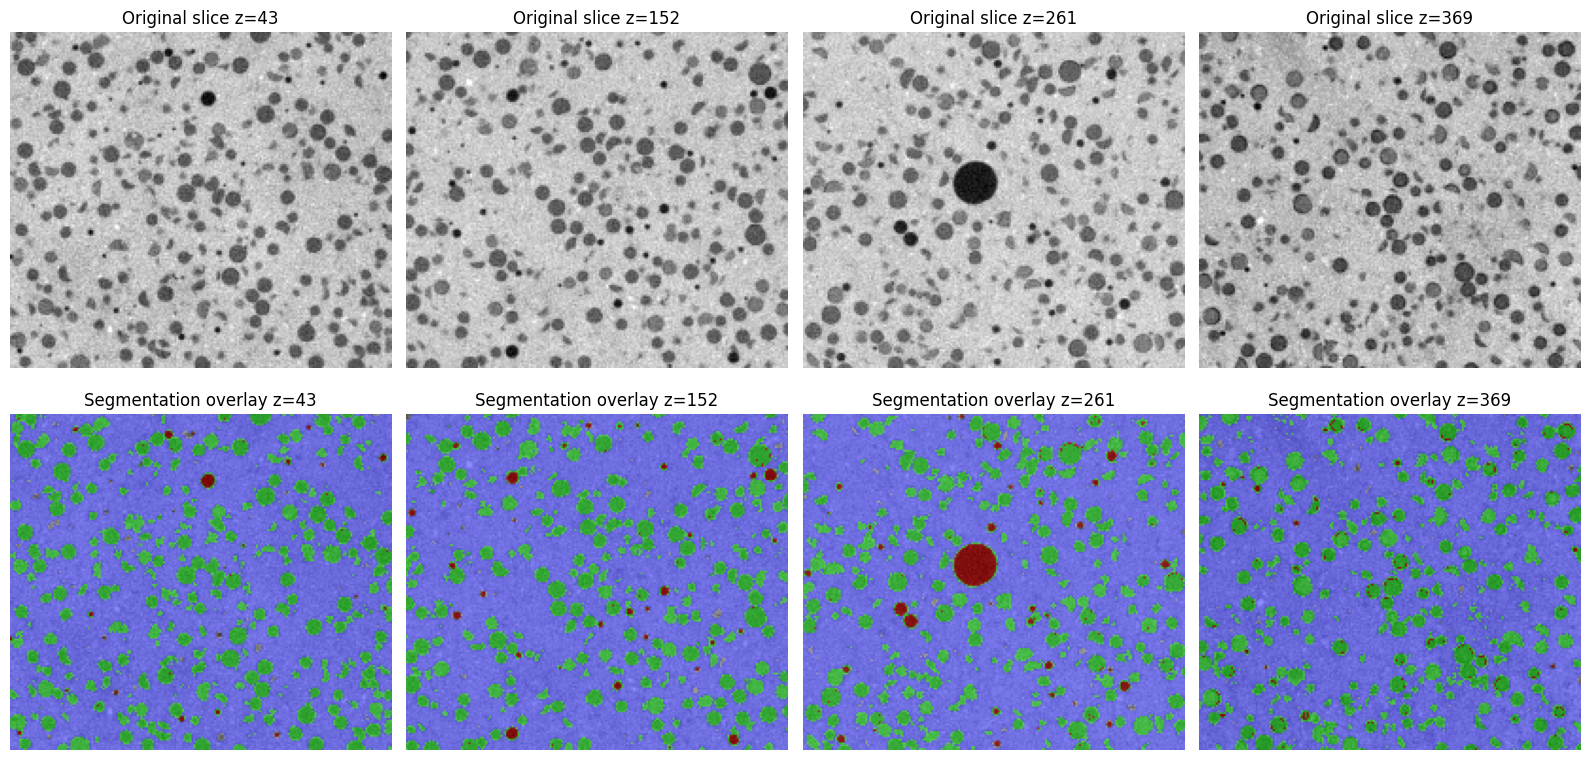

In [13]:
# ------------------------------------------------------------
# Representative slices with segmentation overlays
# ------------------------------------------------------------
# This visual check verifies that the masks loaded from Project 02
# are spatially consistent with the original microCT volume.
# ------------------------------------------------------------

def show_representative_slices(
    volume: np.ndarray,
    mask_pores: np.ndarray,
    mask_resin: np.ndarray,
    mask_matrix: np.ndarray,
    save_path: Path | None = None
) -> None:
    """
    Show representative slices of the original volume and the corresponding
    segmentation overlay.

    Phase overlay:
    - pores  : red
    - resin  : green
    - matrix : blue
    """

    z_indices = [
        int(volume.shape[0] * 0.10),
        int(volume.shape[0] * 0.35),
        int(volume.shape[0] * 0.60),
        int(volume.shape[0] * 0.85),
    ]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    for col, z in enumerate(z_indices):
        img = volume[z]

        # Original image
        axes[0, col].imshow(img, cmap="gray")
        axes[0, col].set_title(f"Original slice z={z}")
        axes[0, col].axis("off")

        # Normalize image for RGB background
        img_float = img.astype(float)
        img_norm = (img_float - img_float.min()) / (
            img_float.max() - img_float.min() + 1e-8
        )

        overlay = np.dstack([img_norm, img_norm, img_norm])

        # Phase masks for current slice
        pores = mask_pores[z]
        resin = mask_resin[z]
        matrix = mask_matrix[z]

        alpha = 0.45

        # pores -> red
        overlay[pores] = (1 - alpha) * overlay[pores] + alpha * np.array([1, 0, 0])

        # resin -> green
        overlay[resin] = (1 - alpha) * overlay[resin] + alpha * np.array([0, 1, 0])

        # matrix -> blue
        overlay[matrix] = (1 - alpha) * overlay[matrix] + alpha * np.array([0, 0, 1])

        axes[1, col].imshow(overlay)
        axes[1, col].set_title(f"Segmentation overlay z={z}")
        axes[1, col].axis("off")

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")

    plt.show()


fig_path = FIGURES_DIR / "representative_slices_with_masks.png"

show_representative_slices(
    volume=volume,
    mask_pores=mask_pores,
    mask_resin=mask_resin,
    mask_matrix=mask_matrix,
    save_path=fig_path
)

In [24]:
# ------------------------------------------------------------
# Slice-wise feature extraction for pores and resin
# ------------------------------------------------------------
# For each z-slice, we compute:
#
# Phase fractions:
# - pore_fraction
# - resin_fraction
# - matrix_fraction
# - assigned_fraction
#
# Intensity features:
# - mean_intensity
# - std_intensity
# - mean intensity by phase
#
# Pore morphology features:
# - pore_object_count
# - mean_pore_area_um2
# - median_pore_area_um2
# - mean_pore_equivalent_diameter_um
# - median_pore_equivalent_diameter_um
#
# Resin morphology features:
# - resin_object_count
# - mean_resin_area_um2
# - median_resin_area_um2
# - mean_resin_equivalent_diameter_um
# - median_resin_equivalent_diameter_um
#
# Heterogeneity:
# - heterogeneity_index
# ------------------------------------------------------------

def compute_2d_object_features(mask_2d: np.ndarray, pixel_area_um2: float) -> dict:
    """
    Compute object-based 2D features for a binary mask in a single slice.

    Parameters
    ----------
    mask_2d : np.ndarray
        Binary mask for one phase in one slice.

    pixel_area_um2 : float
        Pixel area in square micrometers.

    Returns
    -------
    features : dict
        Object count, area statistics and equivalent diameter statistics.
    """

    labeled = measure.label(mask_2d, connectivity=2)
    props = measure.regionprops(labeled)

    object_count = len(props)

    if object_count > 0:
        areas_px = np.array([p.area for p in props])
        areas_um2 = areas_px * pixel_area_um2

        mean_area_um2 = areas_um2.mean()
        median_area_um2 = np.median(areas_um2)

        # Equivalent diameter of a circle with the same area
        equivalent_diameters_um = 2.0 * np.sqrt(areas_um2 / np.pi)

        mean_equivalent_diameter_um = equivalent_diameters_um.mean()
        median_equivalent_diameter_um = np.median(equivalent_diameters_um)

    else:
        mean_area_um2 = np.nan
        median_area_um2 = np.nan
        mean_equivalent_diameter_um = np.nan
        median_equivalent_diameter_um = np.nan

    return {
        "object_count": object_count,
        "mean_area_um2": mean_area_um2,
        "median_area_um2": median_area_um2,
        "mean_equivalent_diameter_um": mean_equivalent_diameter_um,
        "median_equivalent_diameter_um": median_equivalent_diameter_um,
    }


def compute_slice_features(
    volume: np.ndarray,
    mask_pores: np.ndarray,
    mask_resin: np.ndarray,
    mask_matrix: np.ndarray,
    voxel_size_um: float
) -> pd.DataFrame:
    """
    Compute quantitative features slice by slice from a 3D microCT volume
    and previously generated phase masks.
    """

    features = []

    pixel_area_um2 = voxel_size_um ** 2

    for z in range(volume.shape[0]):

        img = volume[z]
        pores = mask_pores[z]
        resin = mask_resin[z]
        matrix = mask_matrix[z]

        n_pixels = img.size

        # ----------------------------------------------------
        # Phase fractions
        # ----------------------------------------------------
        pore_fraction = pores.sum() / n_pixels
        resin_fraction = resin.sum() / n_pixels
        matrix_fraction = matrix.sum() / n_pixels

        assigned = pores | resin | matrix
        assigned_fraction = assigned.sum() / n_pixels

        # ----------------------------------------------------
        # Intensity statistics
        # ----------------------------------------------------
        mean_intensity = img.mean()
        std_intensity = img.std()

        mean_intensity_pores = img[pores].mean() if pores.any() else np.nan
        mean_intensity_resin = img[resin].mean() if resin.any() else np.nan
        mean_intensity_matrix = img[matrix].mean() if matrix.any() else np.nan

        # ----------------------------------------------------
        # Object features for pores
        # ----------------------------------------------------
        pore_features = compute_2d_object_features(
            mask_2d=pores,
            pixel_area_um2=pixel_area_um2
        )

        # ----------------------------------------------------
        # Object features for resin
        # ----------------------------------------------------
        resin_features = compute_2d_object_features(
            mask_2d=resin,
            pixel_area_um2=pixel_area_um2
        )

        # ----------------------------------------------------
        # Heterogeneity index
        # ----------------------------------------------------
        # Simple interpretable metric:
        # standard deviation among phase fractions.
        # ----------------------------------------------------
        phase_fractions = np.array([
            pore_fraction,
            resin_fraction,
            matrix_fraction
        ])

        heterogeneity_index = phase_fractions.std()

        features.append({
            "slice_id": z,
            "z_um": z * voxel_size_um,

            "pore_fraction": pore_fraction,
            "resin_fraction": resin_fraction,
            "matrix_fraction": matrix_fraction,
            "assigned_fraction": assigned_fraction,

            "mean_intensity": mean_intensity,
            "std_intensity": std_intensity,
            "mean_intensity_pores": mean_intensity_pores,
            "mean_intensity_resin": mean_intensity_resin,
            "mean_intensity_matrix": mean_intensity_matrix,

            "pore_object_count": pore_features["object_count"],
            "mean_pore_area_um2": pore_features["mean_area_um2"],
            "median_pore_area_um2": pore_features["median_area_um2"],
            "mean_pore_equivalent_diameter_um": pore_features["mean_equivalent_diameter_um"],
            "median_pore_equivalent_diameter_um": pore_features["median_equivalent_diameter_um"],

            "resin_object_count": resin_features["object_count"],
            "mean_resin_area_um2": resin_features["mean_area_um2"],
            "median_resin_area_um2": resin_features["median_area_um2"],
            "mean_resin_equivalent_diameter_um": resin_features["mean_equivalent_diameter_um"],
            "median_resin_equivalent_diameter_um": resin_features["median_equivalent_diameter_um"],

            "heterogeneity_index": heterogeneity_index,
        })

    return pd.DataFrame(features)

In [25]:
# ------------------------------------------------------------
# Compute slice-wise feature table
# ------------------------------------------------------------

df_features = compute_slice_features(
    volume=volume,
    mask_pores=mask_pores,
    mask_resin=mask_resin,
    mask_matrix=mask_matrix,
    voxel_size_um=VOXEL_SIZE_UM
)

print("Feature table created successfully.")
print(f"Shape: {df_features.shape}")

df_features.head()

Feature table created successfully.
Shape: (435, 22)


,slice_id,z_um,pore_fraction,resin_fraction,matrix_fraction,assigned_fraction,mean_intensity,std_intensity,mean_intensity_pores,mean_intensity_resin,...,mean_pore_area_um2,median_pore_area_um2,mean_pore_equivalent_diameter_um,median_pore_equivalent_diameter_um,resin_object_count,mean_resin_area_um2,median_resin_area_um2,mean_resin_equivalent_diameter_um,median_resin_equivalent_diameter_um,heterogeneity_index
0,0,0.0,0.056875,0.303065,0.622066,0.982006,162.006452,34.223109,76.737897,136.006699,...,52352.000000,19200.0,216.142166,156.352804,592,117805.405405,12800.0,233.533527,127.66153,0.231376
1,1,80.0,0.049366,0.302342,0.638364,0.990071,163.499583,33.344875,77.197183,136.707571,...,45258.964143,12800.0,200.100077,127.661530,769,90473.862159,12800.0,216.507405,127.66153,0.241253
2,2,160.0,0.040800,0.294249,0.657276,0.992324,165.032206,32.662106,77.162236,136.070321,...,35972.413793,12800.0,179.854408,127.661530,755,89684.768212,12800.0,221.468784,127.66153,0.252997
3,3,240.0,0.033513,0.284570,0.673963,0.992046,166.618951,32.181359,77.149378,135.372068,...,30971.887550,12800.0,171.086291,127.661530,704,93018.181818,12800.0,225.478737,127.66153,0.263488
4,4,320.0,0.028952,0.265491,0.697630,0.992074,168.204917,32.126347,77.017291,133.324743,...,25624.615385,12800.0,155.146942,127.661530,672,90914.285714,12800.0,234.745590,127.66153,0.276853


In [26]:
# ------------------------------------------------------------
# Check feature columns and missing values
# ------------------------------------------------------------
# NaN values can appear naturally when a slice has no objects
# for a given phase.
# ------------------------------------------------------------

print("Feature columns:")
for col in df_features.columns:
    print(f"- {col}")

print("\nMissing values by column:")
missing_summary = df_features.isna().sum()
print(missing_summary[missing_summary > 0])

Feature columns:
- slice_id
- z_um
- pore_fraction
- resin_fraction
- matrix_fraction
- assigned_fraction
- mean_intensity
- std_intensity
- mean_intensity_pores
- mean_intensity_resin
- mean_intensity_matrix
- pore_object_count
- mean_pore_area_um2
- median_pore_area_um2
- mean_pore_equivalent_diameter_um
- median_pore_equivalent_diameter_um
- resin_object_count
- mean_resin_area_um2
- median_resin_area_um2
- mean_resin_equivalent_diameter_um
- median_resin_equivalent_diameter_um
- heterogeneity_index

Missing values by column:
Series([], dtype: int64)


In [27]:
# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

selected_columns = [
    "pore_fraction",
    "resin_fraction",
    "matrix_fraction",
    "assigned_fraction",

    "mean_intensity",
    "std_intensity",

    "pore_object_count",
    "mean_pore_equivalent_diameter_um",

    "resin_object_count",
    "mean_resin_equivalent_diameter_um",

    "heterogeneity_index",
]

df_features[selected_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
pore_fraction,435.0,0.012330,0.011771,0.002225,0.004728,0.006675,0.017521,0.056875
resin_fraction,435.0,0.204746,0.016525,0.172878,0.195336,0.203944,0.212551,0.303065
matrix_fraction,435.0,0.778862,0.022066,0.622066,0.769524,0.781761,0.792051,0.819613
assigned_fraction,435.0,0.995937,0.001500,0.978502,0.995467,0.996106,0.996718,0.997886
mean_intensity,435.0,185.013123,3.749169,162.006452,183.696129,186.163644,187.306416,190.242241
std_intensity,435.0,35.709448,3.102792,31.568120,33.613640,34.731792,36.526738,45.933379
pore_object_count,435.0,68.970115,44.783880,20.000000,40.000000,53.000000,86.000000,296.000000
mean_pore_equivalent_diameter_um,435.0,159.359666,33.576099,108.929520,132.790319,155.635866,178.264182,273.782623
resin_object_count,435.0,253.862069,56.395896,201.000000,237.000000,246.000000,256.000000,769.000000
mean_resin_equivalent_diameter_um,435.0,418.262541,31.500018,216.507405,409.612150,419.431079,433.629186,477.639418


In [28]:
# ------------------------------------------------------------
# Save feature table
# ------------------------------------------------------------

features_path = OUTPUTS_DIR / "features_by_slice.csv"

df_features.to_csv(features_path, index=False)

print("Feature table saved to:")
print(features_path)

Feature table saved to:
C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\outputs\features_by_slice.csv


Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\figures\01_feature_table\phase_fraction_profiles.png


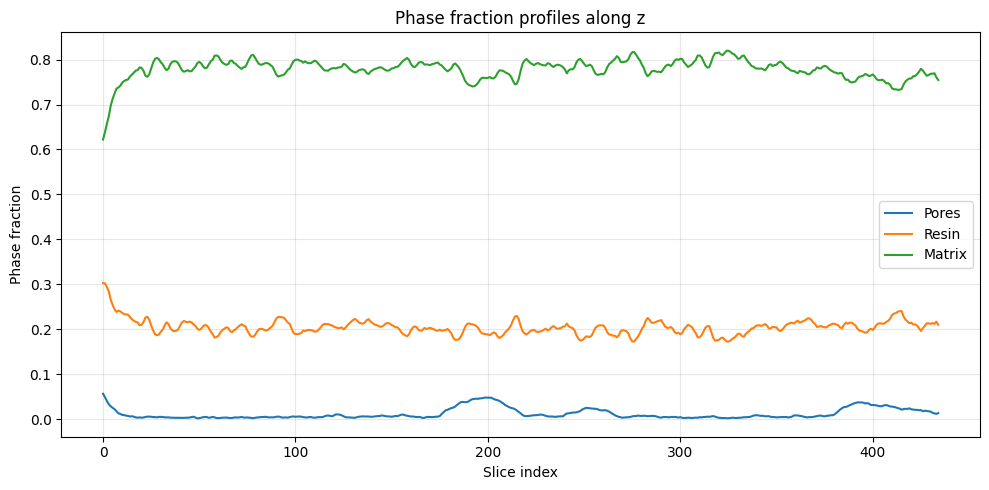

In [29]:
# ------------------------------------------------------------
# Phase fraction profiles along z
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_features["slice_id"], df_features["pore_fraction"], label="Pores")
ax.plot(df_features["slice_id"], df_features["resin_fraction"], label="Resin")
ax.plot(df_features["slice_id"], df_features["matrix_fraction"], label="Matrix")

ax.set_xlabel("Slice index")
ax.set_ylabel("Phase fraction")
ax.set_title("Phase fraction profiles along z")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

fig_path = FIGURES_DIR / "phase_fraction_profiles.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")

plt.show()

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\figures\01_feature_table\pore_object_count_and_size_profiles.png


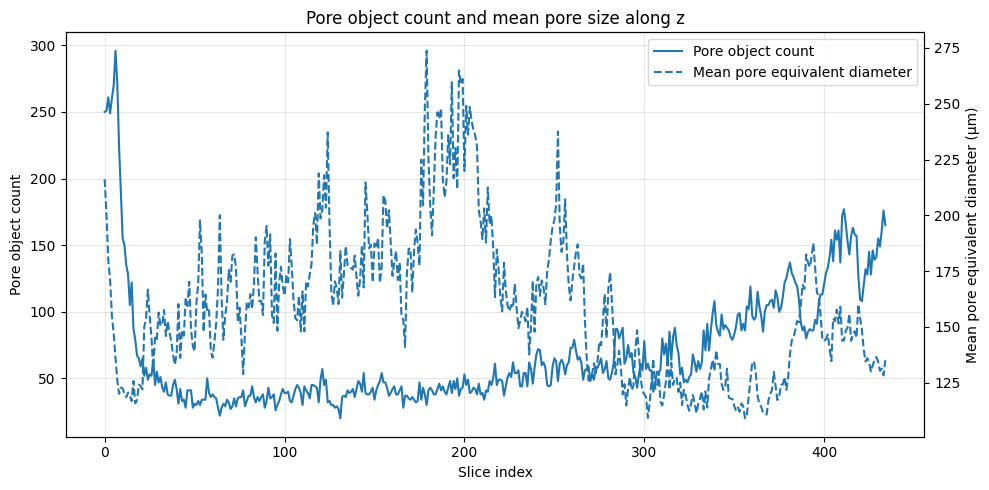

In [30]:
# ------------------------------------------------------------
# Pore object count and mean pore size profiles
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    df_features["slice_id"],
    df_features["pore_object_count"],
    label="Pore object count"
)

ax1.set_xlabel("Slice index")
ax1.set_ylabel("Pore object count")

ax2 = ax1.twinx()

ax2.plot(
    df_features["slice_id"],
    df_features["mean_pore_equivalent_diameter_um"],
    linestyle="--",
    label="Mean pore equivalent diameter"
)

ax2.set_ylabel("Mean pore equivalent diameter (µm)")

ax1.set_title("Pore object count and mean pore size along z")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

ax1.grid(True, alpha=0.3)

plt.tight_layout()

fig_path = FIGURES_DIR / "pore_object_count_and_size_profiles.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")

plt.show()

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\figures\01_feature_table\resin_object_count_and_size_profiles.png


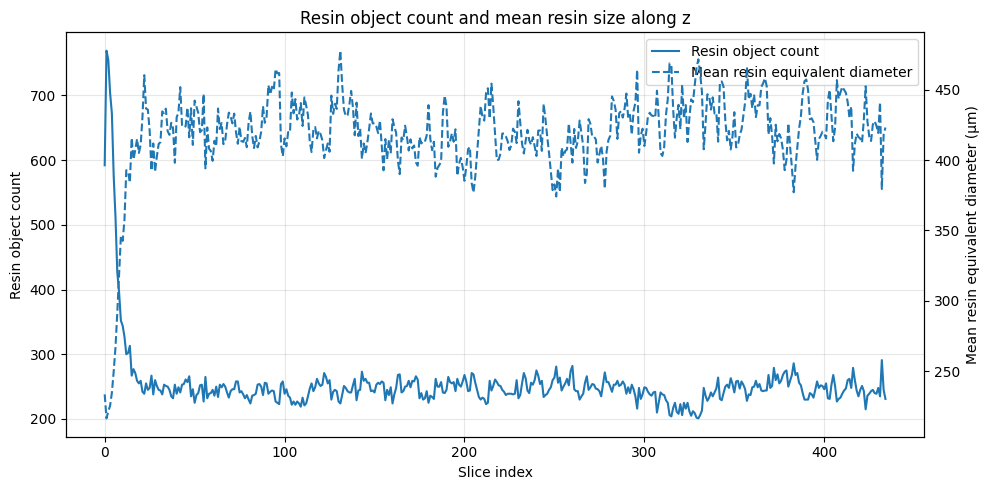

In [31]:
# ------------------------------------------------------------
# Resin object count and mean resin size profiles
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    df_features["slice_id"],
    df_features["resin_object_count"],
    label="Resin object count"
)

ax1.set_xlabel("Slice index")
ax1.set_ylabel("Resin object count")

ax2 = ax1.twinx()

ax2.plot(
    df_features["slice_id"],
    df_features["mean_resin_equivalent_diameter_um"],
    linestyle="--",
    label="Mean resin equivalent diameter"
)

ax2.set_ylabel("Mean resin equivalent diameter (µm)")

ax1.set_title("Resin object count and mean resin size along z")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

ax1.grid(True, alpha=0.3)

plt.tight_layout()

fig_path = FIGURES_DIR / "resin_object_count_and_size_profiles.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")

plt.show()

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\figures\01_feature_table\intensity_and_heterogeneity_profiles.png


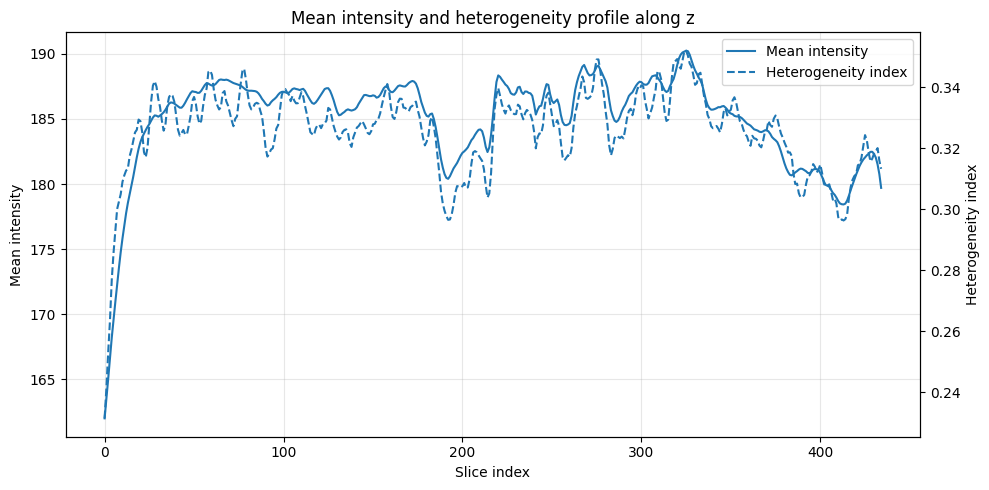

In [32]:
# ------------------------------------------------------------
# Mean intensity and heterogeneity profiles
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    df_features["slice_id"],
    df_features["mean_intensity"],
    label="Mean intensity"
)

ax1.set_xlabel("Slice index")
ax1.set_ylabel("Mean intensity")

ax2 = ax1.twinx()

ax2.plot(
    df_features["slice_id"],
    df_features["heterogeneity_index"],
    linestyle="--",
    label="Heterogeneity index"
)

ax2.set_ylabel("Heterogeneity index")

ax1.set_title("Mean intensity and heterogeneity profile along z")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

ax1.grid(True, alpha=0.3)

plt.tight_layout()

fig_path = FIGURES_DIR / "intensity_and_heterogeneity_profiles.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")

plt.show()

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\figures\01_feature_table\feature_correlation_matrix.png


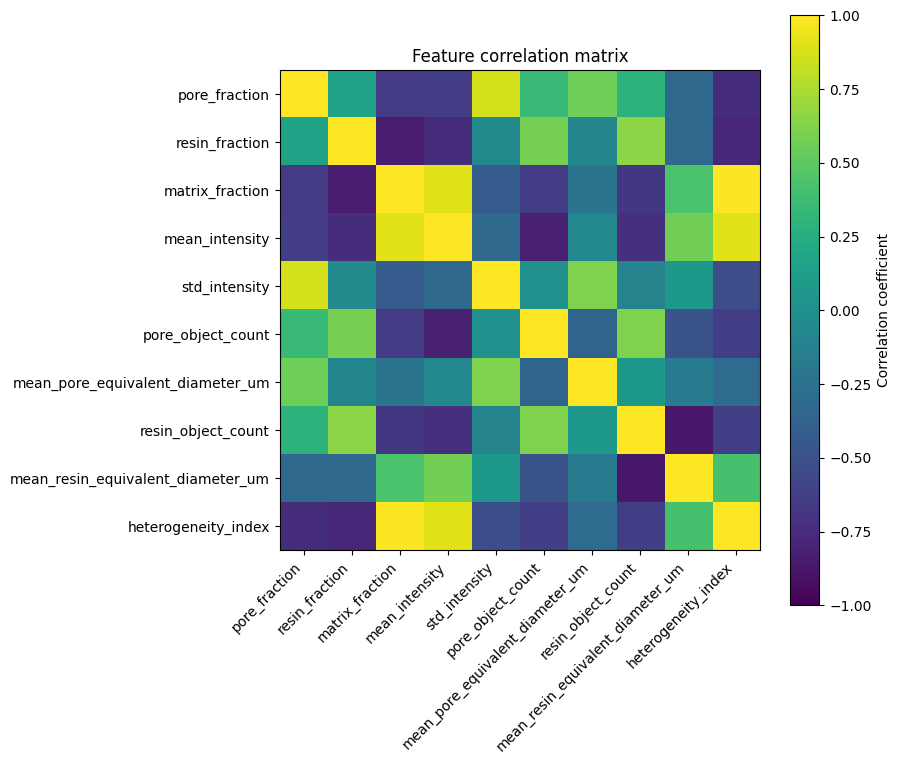

In [33]:
# ------------------------------------------------------------
# Feature correlation matrix
# ------------------------------------------------------------
# This is not a confusion matrix.
# It shows linear relationships between extracted features.
#
# It is useful before anomaly detection because it helps identify:
# - redundant variables
# - physically related features
# - variables that may dominate the anomaly model
# ------------------------------------------------------------

corr_columns = [
    "pore_fraction",
    "resin_fraction",
    "matrix_fraction",

    "mean_intensity",
    "std_intensity",

    "pore_object_count",
    "mean_pore_equivalent_diameter_um",

    "resin_object_count",
    "mean_resin_equivalent_diameter_um",

    "heterogeneity_index",
]

corr = df_features[corr_columns].corr()

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr_columns)))
ax.set_yticks(np.arange(len(corr_columns)))

ax.set_xticklabels(corr_columns, rotation=45, ha="right")
ax.set_yticklabels(corr_columns)

ax.set_title("Feature correlation matrix")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation coefficient")

plt.tight_layout()

fig_path = FIGURES_DIR / "feature_correlation_matrix.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")

plt.show()

In [34]:
# ------------------------------------------------------------
# Final check
# ------------------------------------------------------------

print("Notebook 01 completed successfully.")

print("\nGenerated output table:")
print(f"- {features_path}")

print("\nGenerated figures:")
for file in sorted(FIGURES_DIR.glob("*.png")):
    print(f"- {file.name}")

print("\nNext step:")
print("Use outputs/features_by_slice.csv in Notebook 02 for anomaly detection and quality mapping.")

Notebook 01 completed successfully.

Generated output table:
- C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\outputs\features_by_slice.csv

Generated figures:
- feature_correlation_matrix.png
- intensity_and_heterogeneity_profiles.png
- phase_fraction_profiles.png
- pore_count_and_size_profiles.png
- pore_object_count_and_size_profiles.png
- representative_slices_with_masks.png
- resin_object_count_and_size_profiles.png

Next step:
Use outputs/features_by_slice.csv in Notebook 02 for anomaly detection and quality mapping.
